In [1]:
# Generated by prompting Gemini
# Used steps from the book Bayes Rules! by Johnson, Ott, Doguccu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Read the 'data' tab from the sephora.xlsx file
excel_file_path = '/content/Sephora Kids Linkedin (Responses).xlsx'
sheet_name = 'data'
df = pd.read_excel(excel_file_path, sheet_name=sheet_name)

# Calculate total children observed and total children using makeup from the initial survey
total_children_observed = df['Q1: How many kids aged 9–15 do you personally know?'].sum()
total_children_makeup = df['Q2: How many of those kids use makeup?'].sum()

# Group by 'Source' and calculate the sum of 'Q1' and 'Q2'
total_by_source = df.groupby('Source')[['Q1: How many kids aged 9–15 do you personally know?', 'Q2: How many of those kids use makeup?']].sum()

# Calculate the number of responses per source
response_counts = df.groupby('Source').size().reset_index(name='Number of Responses')

# Merge the total_by_source and response_counts DataFrames
total_by_source = pd.merge(total_by_source, response_counts, on='Source')


# Define the initial prior parameters
alpha_prior_initial = 4
beta_prior_initial = 5

# Calculate the posterior after initial survey
alpha_posterior_initial_survey = alpha_prior_initial + total_children_makeup
beta_posterior_initial_survey = beta_prior_initial + (total_children_observed - total_children_makeup)

# Calculate the posterior after Linkedin data first
linkedin_row = total_by_source[total_by_source['Source'] == 'Linkedin'].iloc[0]
kids_known_linkedin = linkedin_row['Q1: How many kids aged 9–15 do you personally know?']
kids_makeup_linkedin = linkedin_row['Q2: How many of those kids use makeup?']
alpha_posterior_linkedin = alpha_posterior_initial_survey + kids_makeup_linkedin
beta_posterior_linkedin = beta_posterior_initial_survey + (kids_known_linkedin - kids_makeup_linkedin)

# Calculate the posterior after Instagram data second
instagram_row = total_by_source[total_by_source['Source'] == 'Instagram'].iloc[0]
kids_known_instagram = instagram_row['Q1: How many kids aged 9–15 do you personally know?']
kids_makeup_instagram = instagram_row['Q2: How many of those kids use makeup?']
alpha_posterior_instagram = alpha_posterior_linkedin + kids_makeup_instagram
beta_posterior_instagram = beta_posterior_linkedin + (kids_known_instagram - kids_makeup_instagram)

/tmp/ipykernel_149/2535656447.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


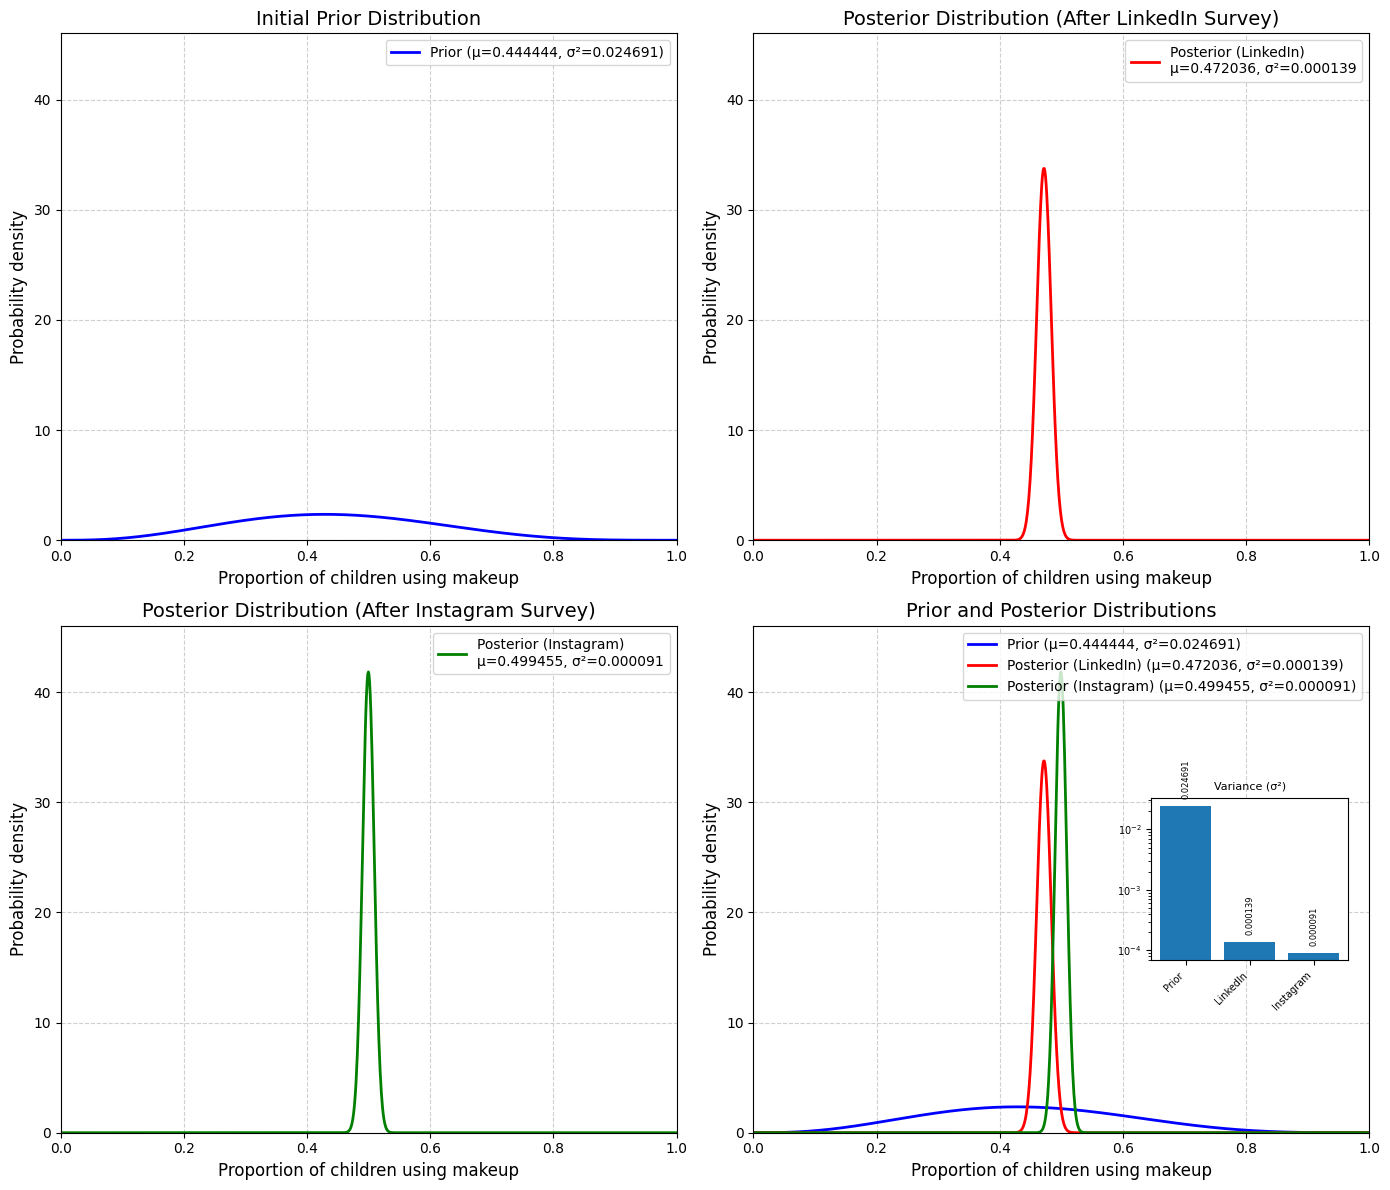

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -------------------------------------------------------------------
# Create PDFs, means, and variances for prior and posteriors
# -------------------------------------------------------------------

# Range of x values
x = np.linspace(0, 1, 1000)

# PDFs
prior_pdf = beta.pdf(x, alpha_prior_initial, beta_prior_initial)
posterior_pdf_linkedin = beta.pdf(x, alpha_posterior_linkedin, beta_posterior_linkedin)
posterior_pdf_instagram = beta.pdf(x, alpha_posterior_instagram, beta_posterior_instagram)

# Means
mean_prior = alpha_prior_initial / (alpha_prior_initial + beta_prior_initial)
mean_posterior_linkedin = alpha_posterior_linkedin / (alpha_posterior_linkedin + beta_posterior_linkedin)
mean_posterior_instagram = alpha_posterior_instagram / (alpha_posterior_instagram + beta_posterior_instagram)

# Variance of Beta(a, b) = a*b / [ (a+b)^2 * (a+b+1) ]
def beta_variance(a, b):
    return a * b / ((a + b) ** 2 * (a + b + 1))

var_prior = beta_variance(alpha_prior_initial, beta_prior_initial)
var_posterior_linkedin = beta_variance(alpha_posterior_linkedin, beta_posterior_linkedin)
var_posterior_instagram = beta_variance(alpha_posterior_instagram, beta_posterior_instagram)

# -------------------------------------------------------------------
# Create figure and axes
# -------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Common x-limits for all panels
for ax in axes.ravel():
    ax.set_xlim(0, 1)

# Common y-limit so changes in width are visually comparable
global_max = max(prior_pdf.max(),
                 posterior_pdf_linkedin.max(),
                 posterior_pdf_instagram.max())
for ax in axes.ravel():
    ax.set_ylim(0, global_max * 1.1)

# -------------------------------------------------------------------
# Top-left: Prior
# -------------------------------------------------------------------
axes[0, 0].plot(
    x,
    prior_pdf,
    label=f'Prior (μ={mean_prior:.6f}, σ²={var_prior:.6f})',
    color='blue',
    linewidth=2
)
axes[0, 0].set_title('Initial Prior Distribution', fontsize=14)
axes[0, 0].set_xlabel('Proportion of children using makeup', fontsize=12)
axes[0, 0].set_ylabel('Probability density', fontsize=12)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------------
# Top-right: Posterior after LinkedIn
# -------------------------------------------------------------------
axes[0, 1].plot(
    x,
    posterior_pdf_linkedin,
    label=(
        f'Posterior (LinkedIn)\n'
        f'μ={mean_posterior_linkedin:.6f}, σ²={var_posterior_linkedin:.6f}'
    ),
    color='red',
    linewidth=2
)
axes[0, 1].set_title('Posterior Distribution (After LinkedIn Survey)', fontsize=14)
axes[0, 1].set_xlabel('Proportion of children using makeup', fontsize=12)
axes[0, 1].set_ylabel('Probability density', fontsize=12)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------------
# Bottom-left: Posterior after Instagram
# -------------------------------------------------------------------
axes[1, 0].plot(
    x,
    posterior_pdf_instagram,
    label=(
        f'Posterior (Instagram)\n'
        f'μ={mean_posterior_instagram:.6f}, σ²={var_posterior_instagram:.6f}'
    ),
    color='green',
    linewidth=2
)
axes[1, 0].set_title('Posterior Distribution (After Instagram Survey)', fontsize=14)
axes[1, 0].set_xlabel('Proportion of children using makeup', fontsize=12)
axes[1, 0].set_ylabel('Probability density', fontsize=12)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------------
# Bottom-right: All three + variance inset
# -------------------------------------------------------------------
axes[1, 1].plot(
    x,
    prior_pdf,
    label=f'Prior (μ={mean_prior:.6f}, σ²={var_prior:.6f})',
    color='blue',
    linewidth=2
)
axes[1, 1].plot(
    x,
    posterior_pdf_linkedin,
    label=f'Posterior (LinkedIn) (μ={mean_posterior_linkedin:.6f}, σ²={var_posterior_linkedin:.6f})',
    color='red',
    linewidth=2
)
axes[1, 1].plot(
    x,
    posterior_pdf_instagram,
    label=f'Posterior (Instagram) (μ={mean_posterior_instagram:.6f}, σ²={var_posterior_instagram:.6f})',
    color='green',
    linewidth=2
)
axes[1, 1].set_title('Prior and Posterior Distributions', fontsize=14)
axes[1, 1].set_xlabel('Proportion of children using makeup', fontsize=12)
axes[1, 1].set_ylabel('Probability density', fontsize=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------------
# Inset: log-scale bar chart of variances to show shrinkage numerically
# -------------------------------------------------------------------
ax_inset = inset_axes(
    axes[1, 1],
    width="32%", height="32%",   # smaller inset
    loc="center right",          # middle-right so it doesn't cut into peaks too much
    borderpad=1.5
)

labels = ['Prior', 'LinkedIn', 'Instagram']
variances = [var_prior, var_posterior_linkedin, var_posterior_instagram]

x_pos = np.arange(len(labels))

bars = ax_inset.bar(x_pos, variances)
ax_inset.set_xticks(x_pos)
ax_inset.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)

# Log scale so tiny posterior variances are visible
ax_inset.set_yscale('log')

ax_inset.set_title('Variance (σ²)', fontsize=8)
ax_inset.tick_params(axis='y', labelsize=7)

# Annotate exact variance values above each bar
for i, v in enumerate(variances):
    ax_inset.text(
        i,
        v * 1.3,              # a bit above the bar
        f'{v:.6f}',
        ha='center',
        va='bottom',
        fontsize=6,
        rotation=90
    )

# -------------------------------------------------------------------
# Layout, save, and show
# -------------------------------------------------------------------
plt.tight_layout()
fig.savefig('all_distributions_2x2_with_variance_inset.png',
            dpi=200, bbox_inches='tight')
plt.show()


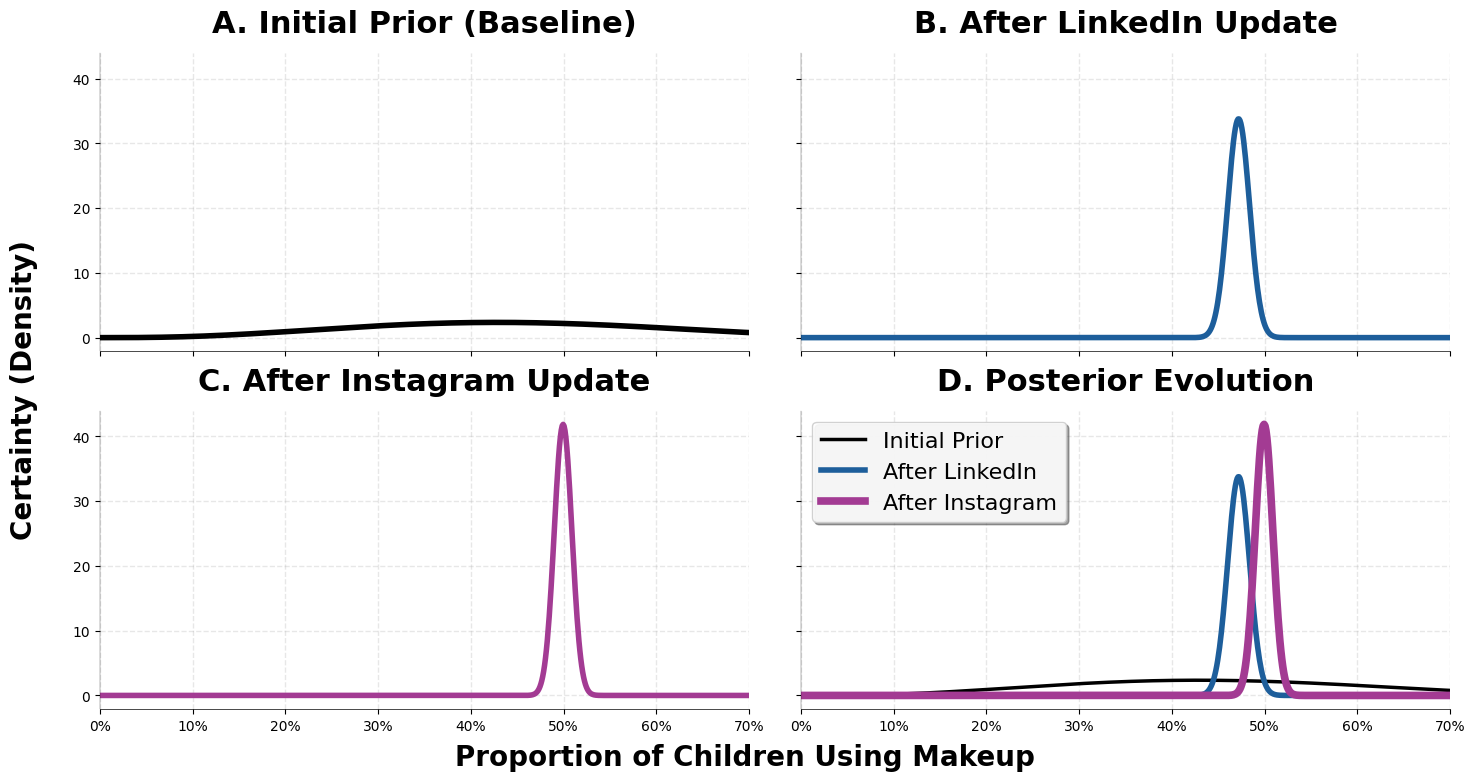

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from matplotlib.lines import Line2D
import matplotlib.ticker as mtick

# --- PRESENTATION CONFIG ---
color_prior = '#000000' # Solid Black
color_li    = '#1d5e9b' # Specific Blue from LinkedIn Chart
color_ig    = '#a33b93' # Specific Magenta/Purple from Instagram Chart

# Create 2x2 grid for 15x8 space
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)

# Tighten margins to make the lines "pop"
plt.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.10, hspace=0.2, wspace=0.08)

x = np.linspace(0, 1, 1000)

def style_ax(ax, title):
    ax.set_title(title, fontsize=22, fontweight='bold', pad=15)
    ax.grid(True, linestyle='--', alpha=0.3, linewidth=1)
    ax.set_xlim(0, 0.70) # ZOOM: Focuses on 0-70% to make curves larger
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for spine in ax.spines.values():
        spine.set_linewidth(2)
# REMOVE BORDERS: Hide top and right lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # OPTIONAL: Make the remaining X and Y lines slightly thicker for "pop"
    ax.spines['left'].set_linewidth(0.2)
    ax.spines['bottom'].set_linewidth(.5)



# Calculation (using your variables)
prior_pdf = beta.pdf(x, alpha_prior_initial, beta_prior_initial)
li_pdf    = beta.pdf(x, alpha_posterior_linkedin, beta_posterior_linkedin)
ig_pdf    = beta.pdf(x, alpha_posterior_instagram, beta_posterior_instagram)

# --- PLOT 1: PRIOR ---
axes[0, 0].plot(x, prior_pdf, color=color_prior, linewidth=4)
style_ax(axes[0, 0], 'A. Initial Prior (Baseline)')

# --- PLOT 2: LINKEDIN ---
axes[0, 1].plot(x, li_pdf, color=color_li, linewidth=4)
style_ax(axes[0, 1], 'B. After LinkedIn Update')

# --- PLOT 3: INSTAGRAM ---
axes[1, 0].plot(x, ig_pdf, color=color_ig, linewidth=4)
style_ax(axes[1, 0], 'C. After Instagram Update')

# --- PLOT 4: COMBINED ---
# Prior is now a SOLID black line
axes[1, 1].plot(x, prior_pdf, color=color_prior, lw=2.5, linestyle='-', label='Initial Prior')
# LinkedIn and Instagram as main data
axes[1, 1].plot(x, li_pdf, color=color_li, lw=4, label='After LinkedIn')
axes[1, 1].plot(x, ig_pdf, color=color_ig, lw=5.5, label='After Instagram')

style_ax(axes[1, 1], 'D. Posterior Evolution')

# Legend in TOP LEFT as requested
axes[1, 1].legend(fontsize=16, frameon=True, shadow=True, loc='upper left', framealpha=0.9)

# Global Labels
fig.text(0.5, 0.03, 'Proportion of Children Using Makeup', ha='center', fontsize=20, fontweight='bold')
fig.text(0.01, 0.5, 'Certainty (Density)', va='center', rotation='vertical', fontsize=20, fontweight='bold')

# Save as High-Res for Presentation
#plt.savefig('sharp_bayesian_solid_prior.png', dpi=400, bbox_inches='tight')
filename = "Sephora_Bayesian_platform_response.svg"
plt.savefig(filename, format='svg', bbox_inches=None)
plt.show()

In [14]:
# Calculate the variance for each stage
variance_prior = beta.var(alpha_prior_initial, beta_prior_initial)
variance_posterior_linkedin = beta.var(alpha_posterior_linkedin, beta_posterior_linkedin)
variance_posterior_instagram = beta.var(alpha_posterior_instagram, beta_posterior_instagram)

# Calculate the 95% credible interval for each stage
# The beta.interval function returns the lower and upper bounds of the interval
ci_prior = beta.interval(0.95, alpha_prior_initial, beta_prior_initial)
ci_posterior_linkedin = beta.interval(0.95, alpha_posterior_linkedin, beta_posterior_linkedin)
ci_posterior_instagram = beta.interval(0.95, alpha_posterior_instagram, beta_posterior_instagram)

# Combine all the data into a single dictionary
combined_data = {
    'Stage': ['Initial Prior', 'After Linkedin Data', 'After Instagram Data'],
    'Mean Proportion': [mean_prior, mean_posterior_linkedin, mean_posterior_instagram],
    'Alpha': [alpha_prior_initial, alpha_posterior_linkedin, alpha_posterior_instagram],
    'Beta': [beta_prior_initial, beta_posterior_linkedin, beta_posterior_instagram],
    'Variance': [variance_prior, variance_posterior_linkedin, variance_posterior_instagram],
    '95% Credible Interval': [ci_prior, ci_posterior_linkedin, ci_posterior_instagram]
}

# Create a pandas DataFrame
combined_df = pd.DataFrame(combined_data)

# Display the DataFrame
display(combined_df)

,Stage,Mean Proportion,Alpha,Beta,Variance,95% Credible Interval
0,Initial Prior,0.444444,4,5,0.024691,"(0.15701277048705797, 0.7551367836334484)"
1,After Linkedin Data,0.472036,844,944,0.000139,"(0.4489351257213044, 0.4951957181919537)"
2,After Instagram Data,0.499455,1374,1377,0.000091,"(0.4807758283801915, 0.5181344100088248)"


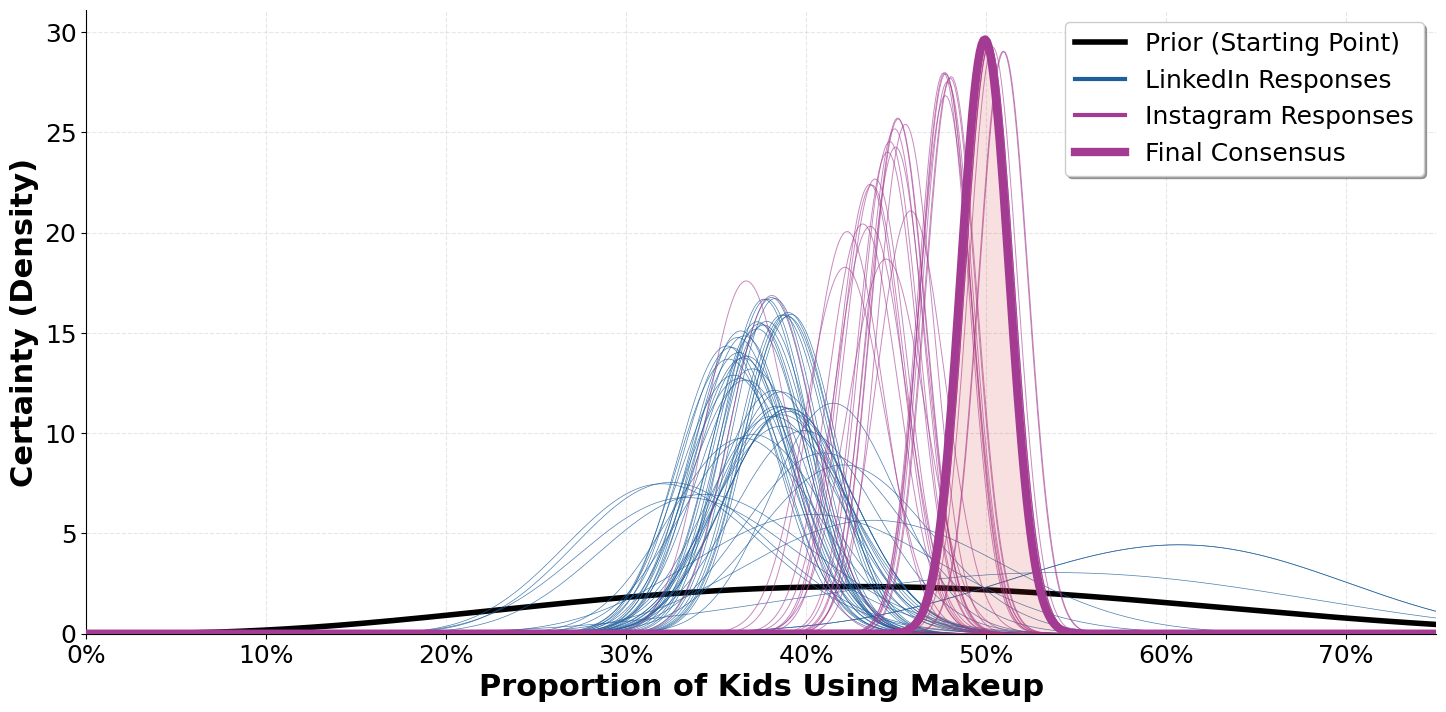

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from matplotlib.lines import Line2D
import matplotlib.ticker as mtick


# 1. Load your data
excel_file_path = '/content/Sephora Kids Linkedin (Responses).xlsx'
sheet_name = 'data'
df = pd.read_excel(excel_file_path, sheet_name=sheet_name)

kids_known  = df['Q1: How many kids aged 9–15 do you personally know?'].values
kids_makeup = df['Q2: How many of those kids use makeup?'].values
sources     = df['Source'].values
n_obs = len(kids_known)

# 2. Setup
alpha0, beta0 = 4, 5
x = np.linspace(0, 1, 1000) # Higher resolution for "sharp" lines
curr_alpha, curr_beta = alpha0, beta0

# 3. High-Contrast Palette

color_prior = '#000000' # Solid Black
color_li    = '#1d5e9b' # Specific Blue from LinkedIn Chart
color_ig    = '#a33b93' # Specific Magenta/Purple from Instagram Chart

color_final = '#d63031' # Red (requested)


# Set figure size to match your 15x8 slide space
plt.figure(figsize=(15, 8), dpi=100)
ax = plt.gca()

# PercentFormatter(1.0) means 1.0 is treated as 100%
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))


# 4. Plot Prior (Thick Black)
plt.plot(x, beta.pdf(x, alpha0, beta0), color=color_prior, lw=4, label='Prior', zorder=2)

# 5. Sequential updates
y_max = 0
for i in range(n_obs):
    curr_alpha += kids_makeup[i]
    curr_beta  += (kids_known[i] - kids_makeup[i])
    y = beta.pdf(x, curr_alpha, curr_beta)
    y_max = max(y_max, np.max(y)) # Track for axis scaling

    if i < n_obs - 1:
        source_name = str(sources[i]).strip().lower()
        if 'instagram' in source_name:
            plt.plot(x, y, color=color_ig, lw=0.7, alpha=0.6, zorder=4)
        else:
            plt.plot(x, y, color=color_li, lw=.5, alpha=0.8, zorder=3)
    else:
        # Final combined posterior (Thick Red)
        plt.plot(x, y, color=color_ig, lw=6, zorder=10)
        plt.fill_between(x, 0, y, color=color_final, alpha=0.15, zorder=9)

# 6. Remove White Space & Zoom Axis
# This focuses only on the area where data exists (typically 0 to 0.7 for this data)
plt.xlim(0, 0.75)
plt.ylim(0, y_max * 1.05) # Adds a tiny 5% buffer at the top

# 7. Presentation Styling (BIG FONTS)
#plt.title('LinkedIn vs Instagram Response Drift', fontsize=28, fontweight='bold', pad=20)
plt.xlabel('Proportion of Kids Using Makeup', fontsize=22, fontweight='bold')
plt.ylabel('Certainty (Density)', fontsize=22, fontweight='bold')

# Legend with thicker lines for visibility
legend_elements = [
    Line2D([0], [0], color=color_prior, lw=4, label='Prior (Starting Point)'),
    Line2D([0], [0], color=color_li, lw=3, label='LinkedIn Responses'),
    Line2D([0], [0], color=color_ig, lw=3, label='Instagram Responses'),
    Line2D([0], [0], color=color_ig, lw=6, label='Final Consensus')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=18, frameon=True, shadow=True)

# Clean up the chart area
plt.grid(alpha=0.3, linestyle='--')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# This command removes almost all exterior white padding
plt.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.12)

# Save with ultra-high resolution
#plt.savefig('sharp_presentation_graph.png', dpi=400, bbox_inches='tight')

filename = "Sephora_Bayesian_all_response.svg"
plt.savefig(filename, format='svg', bbox_inches=None)

plt.show()